# NumerAI Shallow LGBM

In [1]:
import sys
import warnings
from pathlib import Path
import os

import lightgbm as lgb
import pandas as pd

warnings.filterwarnings("ignore")

try:
    NOTEBOOK_PATH = Path(__file__).resolve()
except NameError:
    NOTEBOOK_PATH = Path.cwd() / os.environ.get("JPY_SESSION_NAME", "notebook.ipynb")
    
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from utils.data import (
    align_on_id,
    apply_validation_embargo,
    build_dataset_columns,
    load_benchmark_frame,
    load_feature_set,
    read_parquet_with_id_index,
)
from utils.metrics import calculate_metrics
from utils.model_benchmark import compare_top_models_with_current, record_model_metrics
from utils.postprocessing import build_evaluation_frame, neutralize_by_era, rank_by_era
from utils.visualization import display_metrics_table, plot_metric_over_time

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
print('>> Current Notebook Path:', NOTEBOOK_PATH)


>> Current Notebook Path: c:\dev\numer-AI\models\version_1\v1.5\notebook.ipynb


In [2]:
# No auxiliary targets needed for shallow LGBM.


In [3]:
DATA_VERSION = "v5.2"
DATA_DIR = "../../../data"
TRAIN_PATH = os.path.join(DATA_DIR, DATA_VERSION, "train.parquet")
VALIDATION_PATH = os.path.join(DATA_DIR, DATA_VERSION, "validation.parquet")
VALIDATION_BENCHMARKS_PATH = os.path.join(DATA_DIR, DATA_VERSION, "validation_benchmark_models.parquet")

FEATURE_SET_KEY = ["small"]
CUSTOM_FEATURE_LIST = None
MAIN_TARGET = "target_ender_20"
BENCHMARK_COL = "v52_lgbm_ender20"

# Train/validation embargo (train -> validation)
EMBARGO_ERAS = 4

# LightGBM hyperparameters
LGBM_PARAMS = dict(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=5,
    num_leaves=31,
    colsample_bytree=0.1,
    subsample=0.5,
    subsample_freq=1,
    min_child_samples=2000,
    reg_lambda=0.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

ENABLE_NEUTRALIZATION = False
NEUTRALIZATION_PROPORTION = 0.25

# Notebook run controls
MODEL_NAME = "fa_v1.5.1_lgbm_shallow"
FORCE_HISTORY_OVERWRITE = True
RECORD_HISTORY = False
RETRAIN_ON_FULL_DATA = False


## 1) Load Data
Use the standard loader for the common case, or switch `USE_STANDARD_LOADER = False` to control paths and columns manually.

In [4]:
_, feature_set = load_feature_set(
    features_path=os.path.join(DATA_DIR, DATA_VERSION, "features.json"),
    feature_set_key=FEATURE_SET_KEY,
    feature_list=CUSTOM_FEATURE_LIST,
)

train_columns = build_dataset_columns(feature_set=feature_set, target_cols=[MAIN_TARGET])
validation_columns = build_dataset_columns(feature_set=feature_set, target_cols=[MAIN_TARGET])

train_source = Path(TRAIN_PATH)
validation_source = Path(VALIDATION_PATH)
benchmark_source = Path(VALIDATION_BENCHMARKS_PATH)

train = read_parquet_with_id_index(train_source, columns=train_columns)
validation = read_parquet_with_id_index(validation_source, columns=validation_columns)
validation = apply_validation_embargo(train=train, validation=validation, embargo_eras=EMBARGO_ERAS)

val_benchmarks = load_benchmark_frame(benchmark_path=benchmark_source, benchmark_columns=[BENCHMARK_COL])

train = train.dropna(subset=[MAIN_TARGET])
validation = validation.dropna(subset=[MAIN_TARGET])
validation, val_benchmarks = align_on_id(validation, val_benchmarks)

print("Train shape     :", train.shape)
print("Validation shape:", validation.shape)
print("Feature count   :", len(feature_set))
print("Benchmark col   :", BENCHMARK_COL)
display(validation.head())


Train shape     : (2746268, 44)
Validation shape: (3886183, 44)
Feature count   : 42
Benchmark col   : v52_lgbm_ender20


,era,target_ender_20,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,feature_donnard_groutier_twinkle,feature_elusive_vapoury_accomplice,feature_geminate_crummiest_scourer,feature_glandered_unimproved_peafowl,feature_hempen_unionist_cone,feature_illuminated_gambrel_noria,feature_jacobinical_symmetric_roll,feature_jewish_stained_disembowelment,feature_lacklustre_centroidal_schweitzer,feature_limiest_heliolithic_york,feature_maledictive_latter_psellism,feature_mendelian_undiscording_avion,feature_musicianly_aspirate_creativity,feature_petty_upraised_caddice,feature_pottier_unmanly_collyrium,feature_reclaimed_insurrectional_moneyer,feature_saddening_unsound_rustling,feature_simulated_nonclassified_intercessor,feature_snakiest_somalian_wavelet,feature_splanchnic_notional_pint,feature_strained_equivocal_phoneme,feature_stretchy_spiniest_fizgig,feature_toltec_korean_disfavourer,feature_transisthmian_yogic_linden,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
n000c290e4364875,0579,0.50,2,2,3,2,2,3,3,2,2,0,2,0,2,3,2,4,4,2,2,2,0,3,2,1,2,2,1,2,1,2,4,2,3,2,1,1,1,2,2,1,0,2
n002a15bc5575bbb,0579,0.25,0,4,4,0,1,3,1,1,1,2,1,2,3,0,3,1,1,4,1,1,0,4,3,1,1,4,3,2,0,3,3,1,1,1,1,2,1,4,4,1,1,1
n00309caaa0f955e,0579,0.75,1,1,4,4,0,3,1,4,3,4,3,0,1,4,1,2,2,0,2,3,3,4,4,0,1,4,4,0,0,4,3,1,1,0,0,0,0,1,1,1,4,3
n0039cbdcf835708,0579,0.50,2,2,3,1,4,3,4,3,4,0,2,0,2,3,2,4,4,4,3,2,2,3,1,3,0,2,0,4,2,2,0,2,1,4,3,2,3,3,1,3,2,2
n004143458984f89,0579,0.50,4,1,1,1,0,4,4,1,0,0,1,2,3,0,1,4,0,4,2,2,0,0,0,3,1,3,3,2,1,2,2,4,2,1,3,4,3,3,3,2,0,2


In [5]:
print("Training shallow LGBM on target:", MAIN_TARGET)
print(f"Train shape: {train.shape}  |  Feature count: {len(feature_set)}")
print("Hyperparameters:", LGBM_PARAMS)

X_train = train[feature_set].to_numpy()
y_train = train[MAIN_TARGET].to_numpy()

lgbm_model = lgb.LGBMRegressor(**LGBM_PARAMS)
lgbm_model.fit(X_train, y_train)

print("\nLGBM training complete.")


Training shallow LGBM on target: target_ender_20
Train shape: (2746268, 44)  |  Feature count: 42
Hyperparameters: {'n_estimators': 2000, 'learning_rate': 0.01, 'max_depth': 5, 'num_leaves': 31, 'colsample_bytree': 0.1, 'subsample': 0.5, 'subsample_freq': 1, 'min_child_samples': 2000, 'reg_lambda': 0.0, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}

LGBM training complete.


## 2) Generate Validation Predictions


In [6]:
raw_val_predictions = pd.Series(
    lgbm_model.predict(validation[feature_set].to_numpy()),
    index=validation.index,
    name="prediction",
)

if ENABLE_NEUTRALIZATION:
    print(f">> Neutralization proportion: {NEUTRALIZATION_PROPORTION}")
    final_validation_predictions = neutralize_by_era(
        predictions=raw_val_predictions,
        eras=validation["era"],
        features=validation[feature_set],
        proportion=NEUTRALIZATION_PROPORTION,
        rank_output=True,
    )
else:
    print(">> Neutralization disabled, applying era-wise rank only.")
    final_validation_predictions = rank_by_era(
        predictions=raw_val_predictions,
        eras=validation["era"],
        index=validation.index,
    )

validation_model_frame = validation.loc[final_validation_predictions.index].copy()
print(
    "Final prediction range:",
    (float(final_validation_predictions.min()), float(final_validation_predictions.max())),
)
print("Validation rows:", len(final_validation_predictions))


>> Neutralization disabled, applying era-wise rank only.
Final prediction range: (0.00013681762210972773, 1.0)
Validation rows: 3886183


## 3) Evaluate



Meta-learner metrics:
                             KEY PERFORMANCE METRICS vs GOALS                             


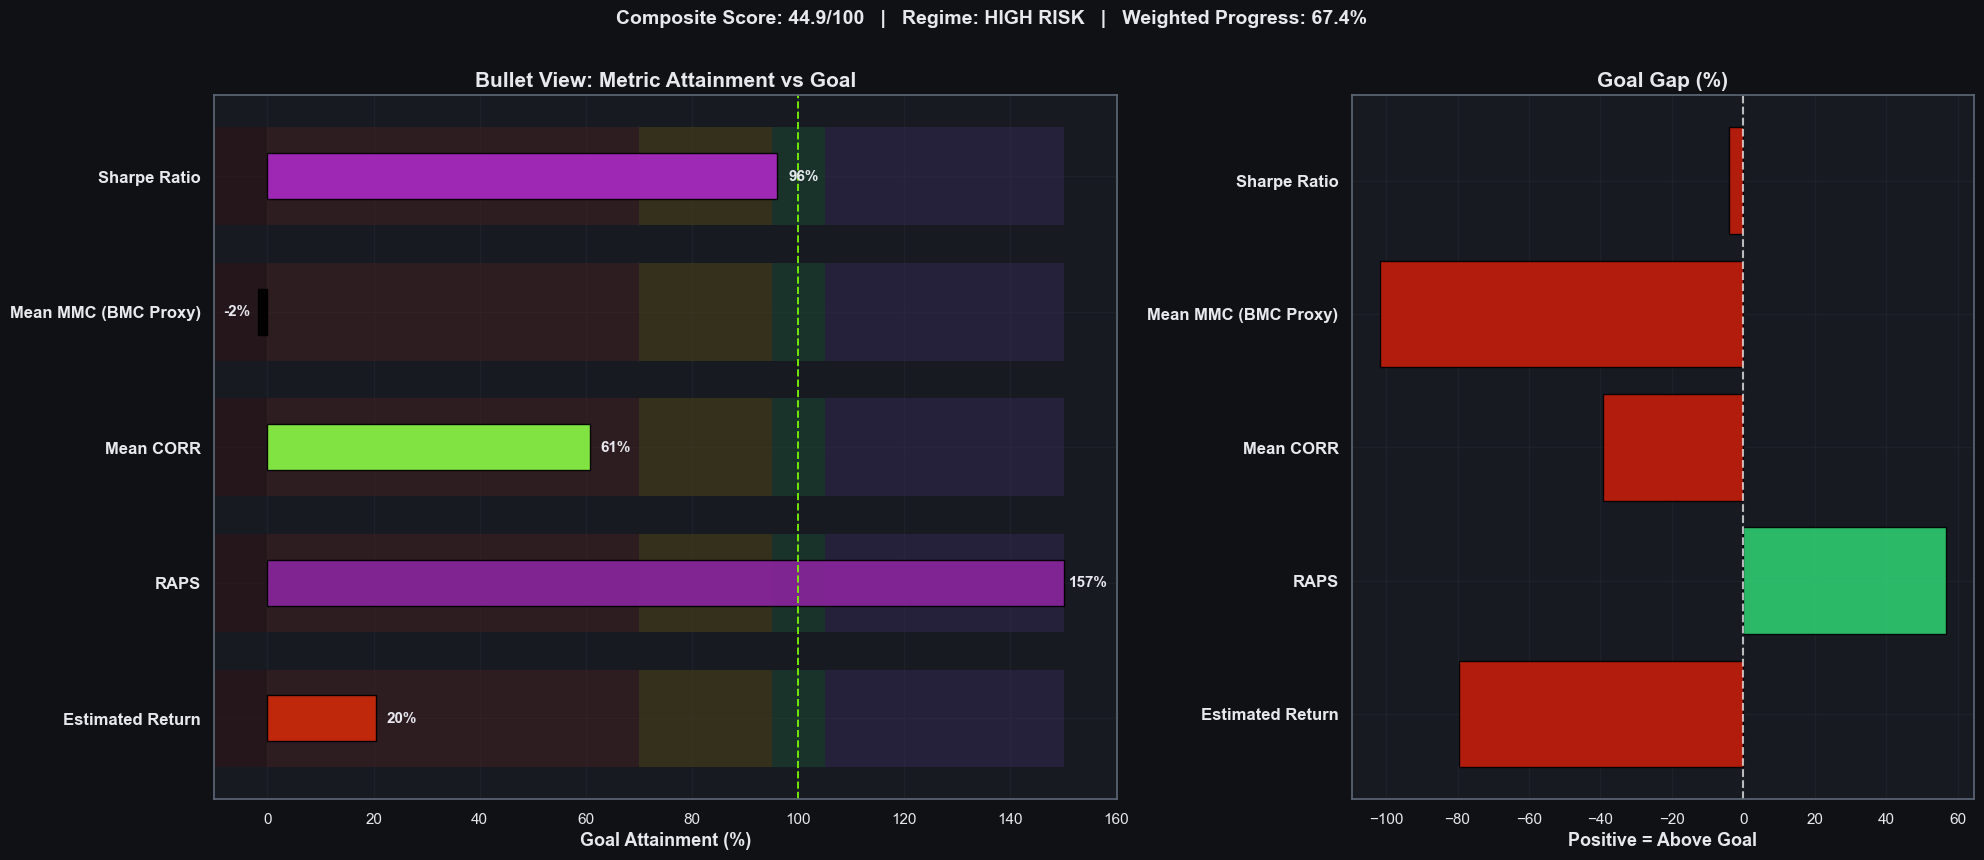

Category,Metric,Value,Goal,Gap %,Progress %,Status,Interpretation
Payout,Estimated Return,+5.11%,+25.00%,-79.5%,20.5%,🔴 BELOW,"Approximate payout percent using 0.75× CORR + 2.25× MMC, capped at +/-5%"
Payout,Mean MMC (BMC Proxy),-0.00017,+0.01000,-101.7%,-1.7%,🔴 BELOW,Uniqueness vs benchmark with the current 2.25× payout weight proxy
Payout,Mean CORR,+0.01337,+0.02200,-39.2%,60.8%,🟠 LAGGING,Official Numerai correlation score; strong models are often 0.01-0.03
Payout,RAPS,+0.1566,+0.1000,+56.6%,156.6%,🟣 ABOVE TARGET !!!,Risk-adjusted payout proxy with drawdown and tail-risk penalties
Quality,Win Rate,82.2%,85.0%,-3.2%,96.8%,🟡 CLOSE,Fraction of eras with positive CORR
Quality,Mean FNC,—,+0.01000,—,—,—,CORR after removing linear feature exposure
Risk,Payout Sharpe,+0.2974,+1.2500,-76.2%,23.8%,🔴 BELOW,Sharpe ratio of payout proxy (0.75× CORR + 2.25× MMC)
Risk,Sharpe Ratio,+0.9610,+1.0000,-3.9%,96.1%,🟡 CLOSE,Risk-adjusted return consistency
Risk,Max Drawdown,-0.08157,-0.10000,+18.4%,118.4%,🟢 MET,Worst sustained CORR cumulative loss
Risk,MMC Volatility,+0.01049,—,—,—,—,Standard deviation of era-by-era MMC


In [7]:
evaluation_frame = build_evaluation_frame(
    validation=validation_model_frame,
    predictions= final_validation_predictions,
    target_col=MAIN_TARGET,
)

metrics, per_era_df = calculate_metrics(
    df_validation=evaluation_frame,
    benchmarks=val_benchmarks,
    features=feature_set,
    target_col=MAIN_TARGET,
    benchmark_col=BENCHMARK_COL,
    fast_metrics=True,
 )

print("\nMeta-learner metrics:")
display_metrics_table(metrics, extended=True)

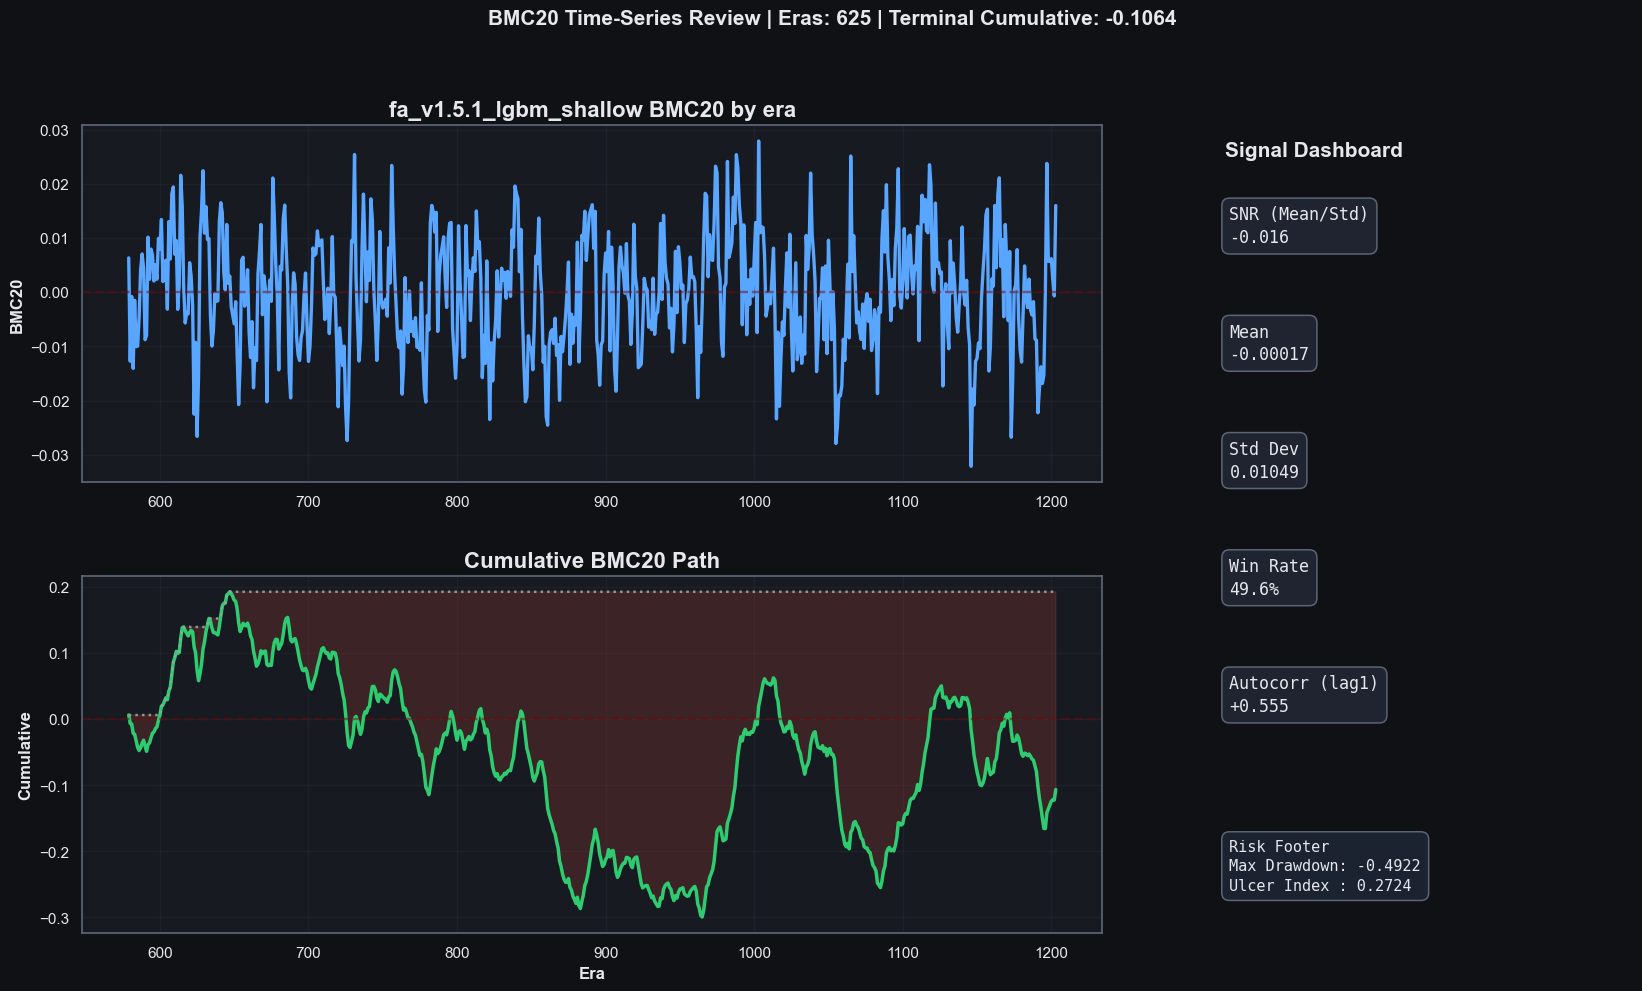

In [8]:
plot_metric_over_time(
    per_era_df=per_era_df,
    metric="BMC20",
    title=f"{MODEL_NAME} BMC20 by era",
)


In [9]:
assert False

AssertionError: 

In [10]:
history_df, record = record_model_metrics(
    metrics=metrics,
    model_name="Shallow LGBM Baseline",
    notebook_name=NOTEBOOK_PATH.name,
    force=FORCE_HISTORY_OVERWRITE,
)
display(pd.DataFrame([record]))


,run_id,model_name,9_Annualized_Return_PCT,4_Mean_BMC20,3_Mean_CORR20V2,1_RAPS,5_Sharpe_CORR,2_Sharpe_Payout,7_Max_Drawdown_CORR,8_Win_Rate,6_Mean_FNC,10_Benchmark_Corr,11_BMC_Volatility,4_Mean_MMC20,11_MMC_Volatility,notebook_name,timestamp_utc,history_path,status,message
0,fbb644a7,Shallow LGBM Baseline,5.1137,-0.00017,0.013375,0.15662,0.96102,0.29741,-0.081574,0.8224,NaN,0.39982,0.010492,-0.00017,0.010492,notebook.ipynb,2026-04-06 19:03:43,C:\dev\numer-AI\submissions\model_metrics_hist...,inserted,Inserted new model metrics.


In [11]:
if record.get("run_id") is None:
    print("Leaderboard comparison skipped because no run was recorded.")
else:
    leaderboard, is_top_model = compare_top_models_with_current(
        current_run_id=record["run_id"],
        top_n=5,
    )

rank,run id,model name,Annualized Return PCT,Mean BMC20,Mean CORR20V2,RAPS,Sharpe CORR,Sharpe Payout,Max Drawdown CORR,Win Rate,Mean FNC,Benchmark Corr,BMC Volatility,MMC Volatility,timestamp utc
#1,dc554dd6,fa_v1.5.1_lgbm_decorr0.00_neu0.50TOP 1,+15.994%,+0.0021668,+0.03163,+1.2347,+1.8778,+1.281,-0.054067,+0.97307,-,+0.85596,+0.0058049,+0.0058049,2026-04-03 19:10:26
#2,c50c4193,fa_v1.5.0_ridge_stacking_tail10TOP 2,+9.5872%,+0.0048656,+0.0089882,+0.38761,+0.65313,+0.48113,-0.11958,+0.73866,-,+0.15183,+0.011902,+0.011902,2026-04-03 16:55:25
#3,fbb644a7,Shallow LGBM BaselineTOP 3CURRENT RUN,+5.1137%,-0.00017024,+0.013375,+0.15662,+0.96102,+0.29741,-0.081574,+0.8224,-,+0.39982,+0.010492,+0.010492,2026-04-06 19:03:43
#4,7d85f24f,ridge_baseline_template,+3.6996%,-0.00038894,+0.010567,-0.26594,+0.7651,+0.2014,-0.158,+0.7744,-,+0.32543,+0.011406,+0.011406,2026-03-29 18:15:25
#5,096fface,previous_era_target_mean,-0.25314%,-8.3872e-05,-0.00032203,-0.19054,-0.026164,-0.012723,-0.36695,+0.47218,-,+7.5847e-05,+0.011045,+0.011045,2026-03-29 18:20:57


## 4) Full-Data Retrain & Export
Retrain LGBM on merged train + full validation, then export a self-contained `predict` pickle.


In [ ]:
assert False

In [14]:


full_validation = read_parquet_with_id_index(validation_source, columns=validation_columns)
full_validation = full_validation.dropna(subset=[MAIN_TARGET])

full_dataset = pd.concat([train.dropna(subset=[MAIN_TARGET]), full_validation], axis=0)
full_dataset = full_dataset[~full_dataset.index.duplicated(keep="last")].sort_index()

print("Full merged dataset rows:", full_dataset.shape[0])
print("Total eras              :", full_dataset["era"].nunique())

X_full = full_dataset[feature_set].to_numpy()
y_full = full_dataset[MAIN_TARGET].to_numpy()

full_lgbm_model = lgb.LGBMRegressor(**LGBM_PARAMS)
full_lgbm_model.fit(X_full, y_full)

print("Full-data LGBM training complete.")


Full merged dataset rows: 6655142
Total eras              : 1203
Full-data LGBM training complete.


In [15]:
import cloudpickle
import numpy as np


if "full_lgbm_model" not in globals():
    raise ValueError("Run the full-data retrain cell first.")

feature_cols = list(feature_set)
lgbm_booster = full_lgbm_model.booster_

def _rank_by_era_local(values, eras):
    return values.groupby(eras).rank(method="first", pct=True).astype(float)

def predict(live_features, live_benchmark_models):
    del live_benchmark_models

    missing_cols = [col for col in feature_cols if col not in live_features.columns]
    if missing_cols:
        raise ValueError(f"Missing feature columns ({len(missing_cols)}): {', '.join(missing_cols[:10])}")

    live_X = live_features[feature_cols].astype(float).to_numpy()
    live_eras = (
        live_features["era"].astype(str)
        if "era" in live_features.columns
        else pd.Series("0000", index=live_features.index)
    )

    raw_pred = pd.Series(
        lgbm_booster.predict(live_X),
        index=live_features.index,
        name="prediction",
    )

    final_pred = _rank_by_era_local(raw_pred, live_eras)
    return final_pred.clip(lower=0.0, upper=1.0).to_frame("prediction")

export_path = "experiment_lgbm_shallow.pkl"
with open(export_path, "wb") as f:
    f.write(cloudpickle.dumps(predict))

print(f"Exported: {export_path}")
print("predict(live_features, live_benchmark_models) -> DataFrame['prediction']")
print("Self-contained: no utils.* imports at inference time.")


Exported: experiment_lgbm_shallow.pkl
predict(live_features, live_benchmark_models) -> DataFrame['prediction']
Self-contained: no utils.* imports at inference time.


------------------------
-------------
# Overfitted validation 


Leaky sanity-check metrics (full-data retrain on validation):
                             KEY PERFORMANCE METRICS vs GOALS                             


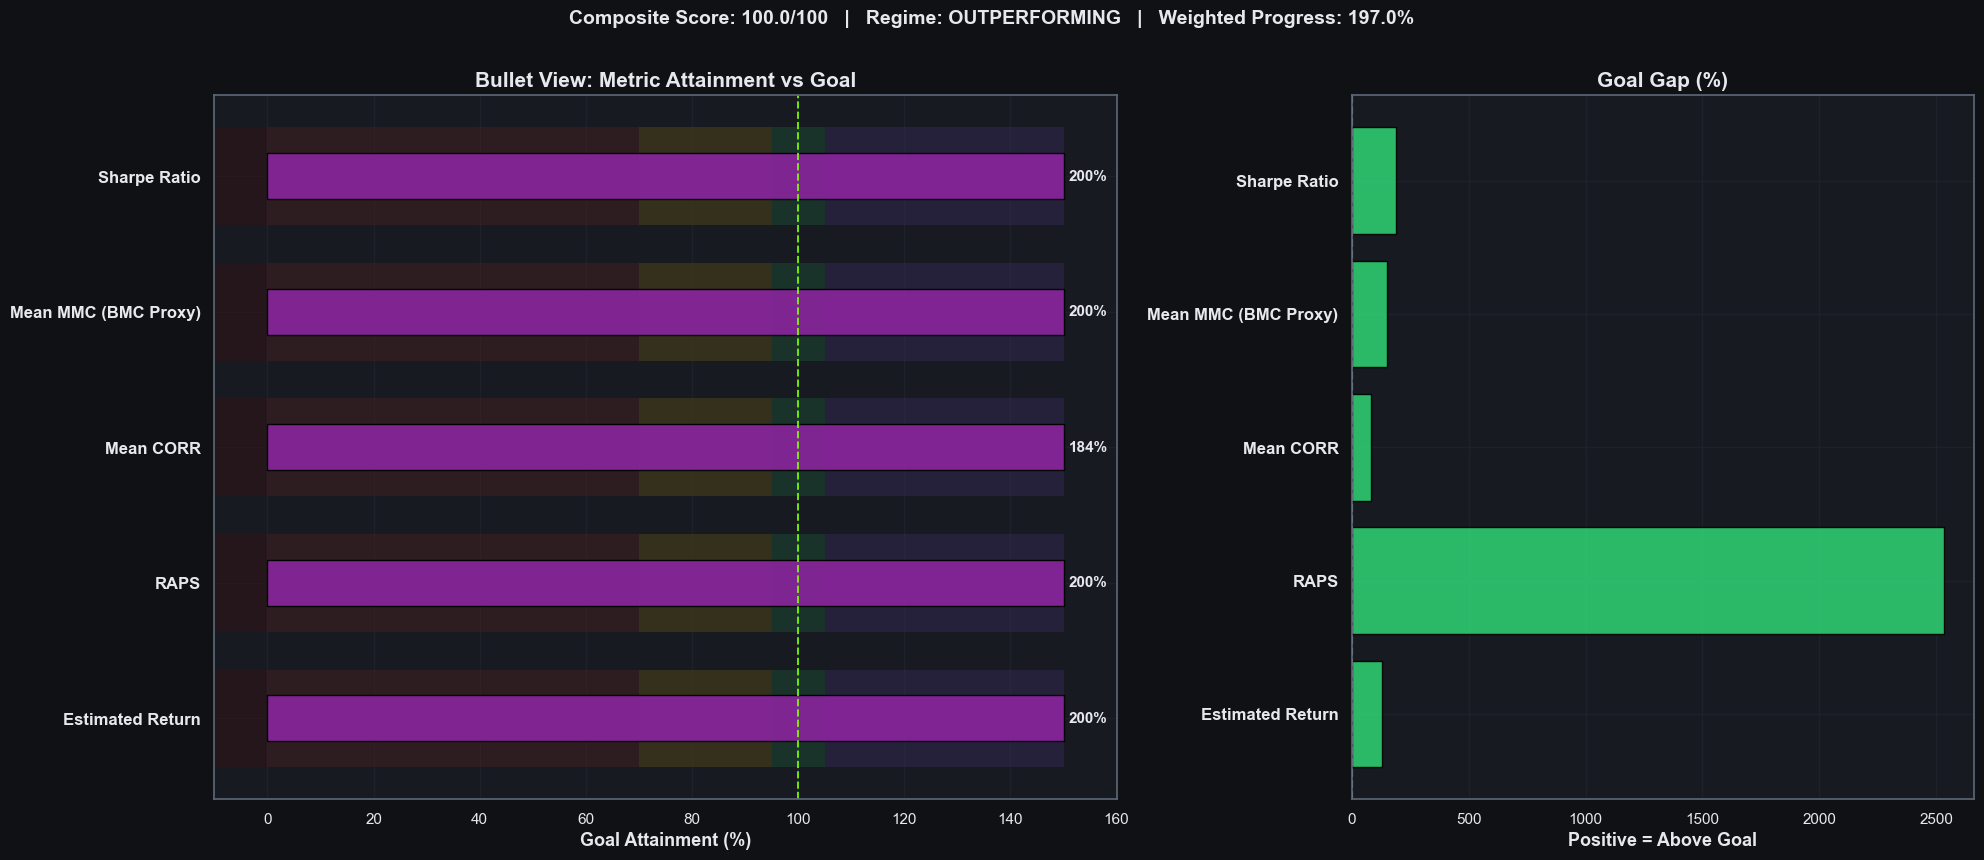

Category,Metric,Value,Goal,Gap %,Progress %,Status,Interpretation
Payout,Estimated Return,+56.97%,+25.00%,+127.9%,200.0%,🟣 ABOVE TARGET !!!,"Approximate payout percent using 0.75× CORR + 2.25× MMC, capped at +/-5%"
Payout,Mean CORR,+0.04048,+0.02200,+84.0%,184.0%,🟣 ABOVE TARGET !!!,Official Numerai correlation score; strong models are often 0.01-0.03
Payout,Mean MMC (BMC Proxy),+0.02523,+0.01000,+152.3%,200.0%,🟣 ABOVE TARGET !!!,Uniqueness vs benchmark with the current 2.25× payout weight proxy
Payout,RAPS,+2.6346,+0.1000,+2534.6%,200.0%,🟣 ABOVE TARGET !!!,Risk-adjusted payout proxy with drawdown and tail-risk penalties
Quality,Win Rate,100.0%,85.0%,+17.6%,117.6%,🟢 MET,Fraction of eras with positive CORR
Quality,Mean FNC,—,+0.01000,—,—,—,CORR after removing linear feature exposure
Risk,Max Drawdown,-0.00000,-0.10000,+100.0%,200.0%,🟣 ABOVE TARGET !!!,Worst sustained CORR cumulative loss
Risk,Payout Sharpe,+2.6387,+1.2500,+111.1%,200.0%,🟣 ABOVE TARGET !!!,Sharpe ratio of payout proxy (0.75× CORR + 2.25× MMC)
Risk,Sharpe Ratio,+2.8764,+1.0000,+187.6%,200.0%,🟣 ABOVE TARGET !!!,Risk-adjusted return consistency
Risk,MMC Volatility,+0.01061,—,—,—,—,Standard deviation of era-by-era MMC


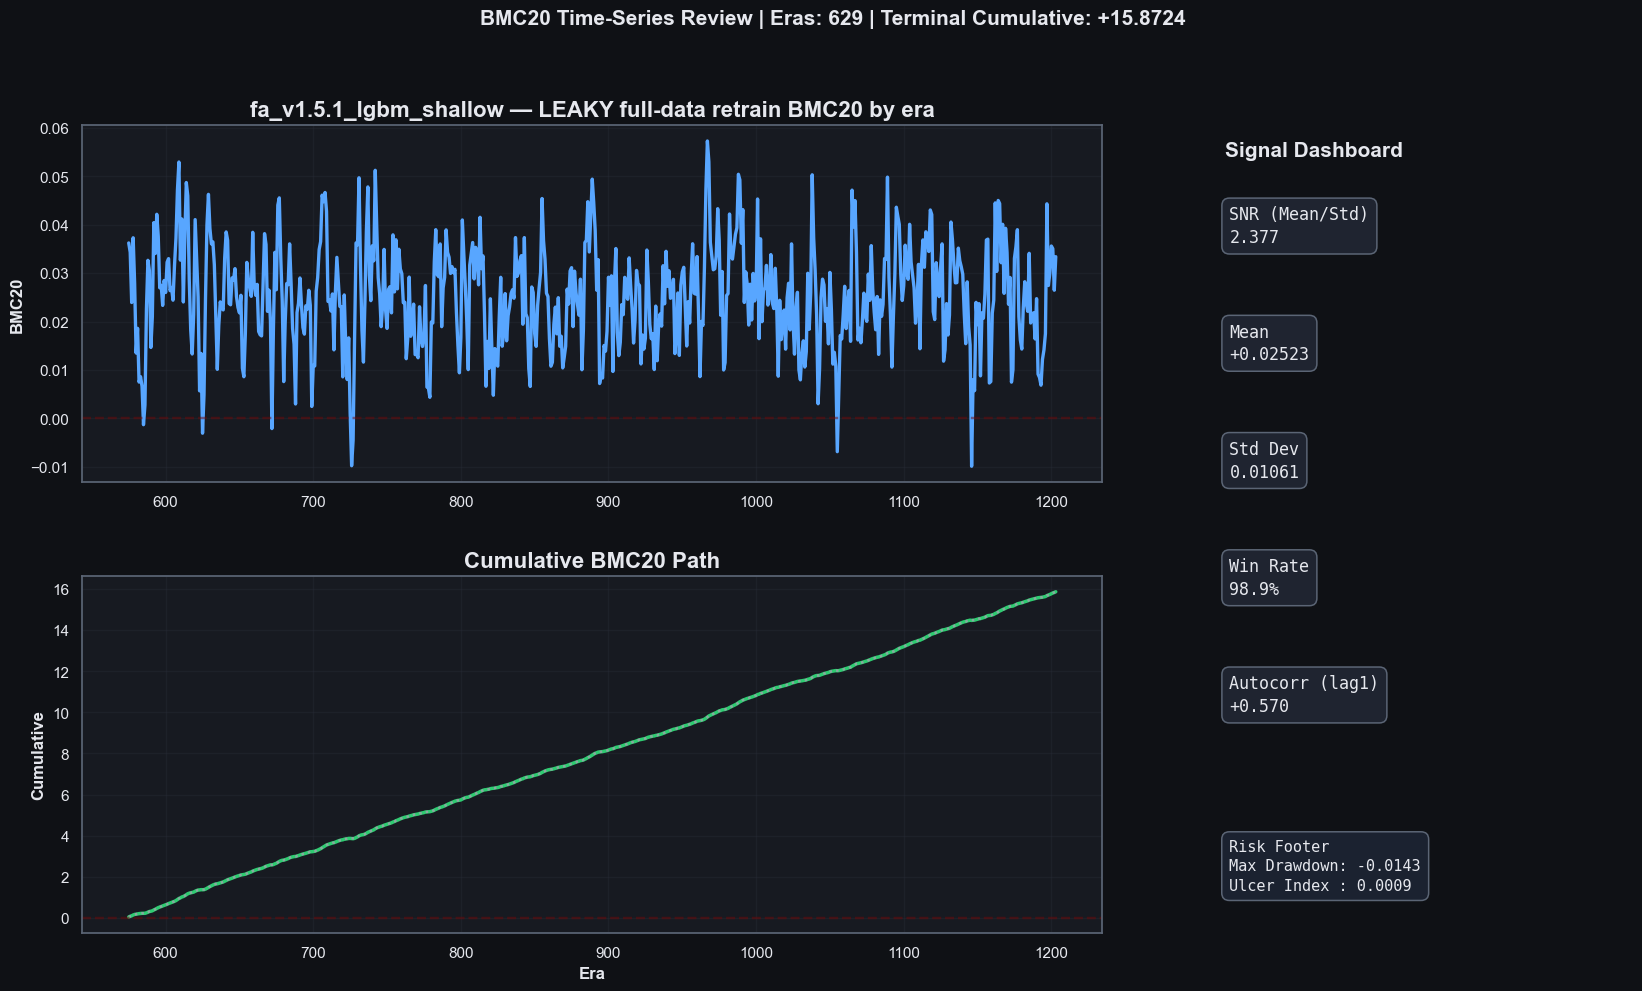

In [16]:
# Sanity check: evaluate full-data model on validation (intentionally leaky).
# Expect significantly inflated metrics vs the hold-out evaluation above.
print("WARNING: leaky evaluation — full_lgbm_model was trained on validation data.")

full_val_eval = read_parquet_with_id_index(validation_source, columns=validation_columns)
full_val_eval = full_val_eval.dropna(subset=[MAIN_TARGET])

full_val_benchmarks = load_benchmark_frame(benchmark_path=benchmark_source, benchmark_columns=[BENCHMARK_COL])
full_val_eval, full_val_benchmarks = align_on_id(full_val_eval, full_val_benchmarks)

leaky_raw = pd.Series(
    full_lgbm_model.predict(full_val_eval[feature_set].to_numpy()),
    index=full_val_eval.index,
    name="prediction",
)
leaky_preds = rank_by_era(
    predictions=leaky_raw,
    eras=full_val_eval["era"],
    index=full_val_eval.index,
)

leaky_eval_frame = build_evaluation_frame(
    validation=full_val_eval.loc[leaky_preds.index],
    predictions=leaky_preds,
    target_col=MAIN_TARGET,
)

leaky_metrics, leaky_per_era = calculate_metrics(
    df_validation=leaky_eval_frame,
    benchmarks=full_val_benchmarks,
    features=feature_set,
    target_col=MAIN_TARGET,
    benchmark_col=BENCHMARK_COL,
    fast_metrics=True,
)

print("\nLeaky sanity-check metrics (full-data retrain on validation):")
display_metrics_table(leaky_metrics, extended=True)

plot_metric_over_time(
    per_era_df=leaky_per_era,
    metric="BMC20",
    title=f"{MODEL_NAME} — LEAKY full-data retrain BMC20 by era",
)
